# Forest Loss Data Cleaning 

## 1,. Data Country tree Cover  Loss

# Load Data

In [5]:
import pandas as pd

dc = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Country tree cover loss')
dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          8 non-null      object
 1   threshold        8 non-null      int64 
 2   area_ha          8 non-null      int64 
 3   extent_2000_ha   8 non-null      int64 
 4   extent_2010_ha   8 non-null      int64 
 5   tc_loss_ha_2001  8 non-null      int64 
 6   tc_loss_ha_2002  8 non-null      int64 
 7   tc_loss_ha_2003  8 non-null      int64 
 8   tc_loss_ha_2004  8 non-null      int64 
 9   tc_loss_ha_2005  8 non-null      int64 
 10  tc_loss_ha_2006  8 non-null      int64 
 11  tc_loss_ha_2007  8 non-null      int64 
 12  tc_loss_ha_2008  8 non-null      int64 
 13  tc_loss_ha_2009  8 non-null      int64 
 14  tc_loss_ha_2010  8 non-null      int64 
 15  tc_loss_ha_2011  8 non-null      int64 
 16  tc_loss_ha_2012  8 non-null      int64 
 17  tc_loss_ha_2013  8 non-null      int64 

In [7]:
dc.head()

,country,threshold,area_ha,extent_2000_ha,extent_2010_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
0,Indonesia,0,189023581,189023581,189023581,754493,864967,549193,1303370,1196068,...,2598728,1449331,1363600,1336079,1071763,953795,1002528,1668215,1313569,1370727
1,Indonesia,10,189023581,165098316,162773868,748273,859053,546506,1294312,1186613,...,2459863,1332280,1247352,1206947,983067,862486,908032,1446292,1156289,1199377
2,Indonesia,15,189023581,163637408,160771739,747168,858052,546052,1292851,1185300,...,2448892,1322837,1238703,1197866,976622,856105,901046,1430519,1145087,1187591
3,Indonesia,20,189023581,162782347,160094433,745905,856856,545515,1291214,1184183,...,2439830,1315087,1231524,1190440,971214,850661,895303,1418070,1136263,1178351
4,Indonesia,25,189023581,161883065,158970716,745097,856082,545180,1290158,1183366,...,2433598,1310033,1226970,1185513,967737,847351,891666,1409593,1130500,1172430


In [11]:
dc.shape

(8, 30)

In [17]:
dc['threshold'].value_counts().sort_index()

threshold
0     1
10    1
15    1
20    1
25    1
30    1
50    1
75    1
Name: count, dtype: int64

## Filter threshold = 30

In [33]:
dcf = dc[dc['threshold'] == 30]

In [35]:
dcf.head()

,country,threshold,area_ha,extent_2000_ha,extent_2010_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
5,Indonesia,30,189023581,160640822,157792891,744084,855270,544812,1289035,1182436,...,2422066,1300718,1218733,1176883,961585,841390,885237,1395285,1120264,1161831


# Check Missing Value

In [52]:
dcf.isnull().sum()

country            0
threshold          0
area_ha            0
extent_2000_ha     0
extent_2010_ha     0
tc_loss_ha_2001    0
tc_loss_ha_2002    0
tc_loss_ha_2003    0
tc_loss_ha_2004    0
tc_loss_ha_2005    0
tc_loss_ha_2006    0
tc_loss_ha_2007    0
tc_loss_ha_2008    0
tc_loss_ha_2009    0
tc_loss_ha_2010    0
tc_loss_ha_2011    0
tc_loss_ha_2012    0
tc_loss_ha_2013    0
tc_loss_ha_2014    0
tc_loss_ha_2015    0
tc_loss_ha_2016    0
tc_loss_ha_2017    0
tc_loss_ha_2018    0
tc_loss_ha_2019    0
tc_loss_ha_2020    0
tc_loss_ha_2021    0
tc_loss_ha_2022    0
tc_loss_ha_2023    0
tc_loss_ha_2024    0
tc_loss_ha_2025    0
dtype: int64

## Check Duplicate

In [57]:
dcf.duplicated().sum()

0

## Identifikasi Forest Loss Column

In [64]:
loss_col = [
    col for col in dcf.columns
    if col.startswith('tc_loss_ha')
]
print(len(loss_col))

25


## Pivot Column From Wide to Long Format

In [112]:
dc_clean = pd.melt(
    dcf,
    id_vars=['country', 'threshold'],
    value_vars= ['tc_loss_ha_2001',    
                    'tc_loss_ha_2002',    
                    'tc_loss_ha_2003',   
                    'tc_loss_ha_2004',    
                    'tc_loss_ha_2005',    
                    'tc_loss_ha_2006',   
                    'tc_loss_ha_2007',    
                    'tc_loss_ha_2008',    
                    'tc_loss_ha_2009',    
                    'tc_loss_ha_2010',   
                    'tc_loss_ha_2011',    
                    'tc_loss_ha_2012',    
                    'tc_loss_ha_2013',    
                    'tc_loss_ha_2014',    
                    'tc_loss_ha_2015',    
                    'tc_loss_ha_2016',    
                    'tc_loss_ha_2017',    
                    'tc_loss_ha_2018',    
                    'tc_loss_ha_2019',    
                    'tc_loss_ha_2020',    
                    'tc_loss_ha_2021',    
                    'tc_loss_ha_2022',    
                    'tc_loss_ha_2023',    
                    'tc_loss_ha_2024',
                    'tc_loss_ha_2025'],
    var_name='year',
    value_name='tree_cover_loss_ha'
)

In [114]:
dc_clean['year'] = (
    dc_clean['year']
    .str.replace('tc_loss_ha_', '')
    .astype(int)
)

In [116]:
dc_clean.head()

,country,threshold,year,tree_cover_loss_ha
0,Indonesia,30,2001,744084
1,Indonesia,30,2002,855270
2,Indonesia,30,2003,544812
3,Indonesia,30,2004,1289035
4,Indonesia,30,2005,1182436


In [118]:
dc_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country             25 non-null     object
 1   threshold           25 non-null     int64 
 2   year                25 non-null     int32 
 3   tree_cover_loss_ha  25 non-null     int64 
dtypes: int32(1), int64(2), object(1)
memory usage: 832.0+ bytes


In [120]:
dc_clean.isna().sum()

country               0
threshold             0
year                  0
tree_cover_loss_ha    0
dtype: int64

In [122]:
dc_clean.duplicated().sum()

0

In [124]:
dc_clean.describe()

,threshold,year,tree_cover_loss_ha
count,25.0,25.000000,2.500000e+01
mean,30.0,2013.000000,1.324997e+06
std,0.0,7.359801,4.529779e+05
min,30.0,2001.000000,5.448120e+05
25%,30.0,2007.000000,1.120264e+06
50%,30.0,2013.000000,1.279328e+06
75%,30.0,2019.000000,1.433147e+06
max,30.0,2025.000000,2.422066e+06


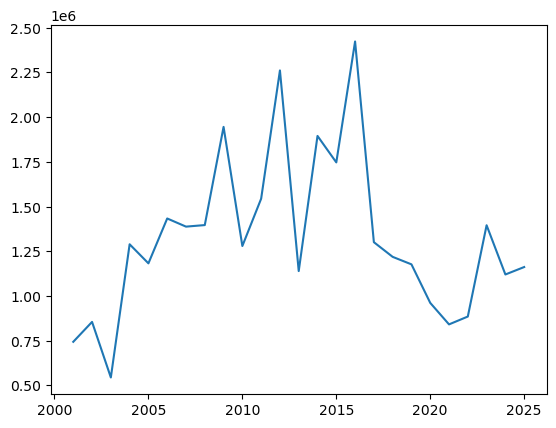

In [126]:
import matplotlib.pyplot as plt

plt.plot(
    dc_clean["year"],
    dc_clean["tree_cover_loss_ha"]
)
plt.show()

## Save Data

In [129]:
dc_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\country_tree_cover_loss.csv', index=False)

print("Save Complete")

Save Complete


## 2. Subnational 1 tree cover loss

## Load Data

In [1]:
import pandas as pd

ds = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Subnational 1 tree cover loss')
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          272 non-null    object
 1   subnational1     272 non-null    object
 2   threshold        272 non-null    int64 
 3   area_ha          272 non-null    int64 
 4   extent_2000_ha   272 non-null    int64 
 5   extent_2010_ha   272 non-null    int64 
 6   tc_loss_ha_2001  272 non-null    int64 
 7   tc_loss_ha_2002  272 non-null    int64 
 8   tc_loss_ha_2003  272 non-null    int64 
 9   tc_loss_ha_2004  272 non-null    int64 
 10  tc_loss_ha_2005  272 non-null    int64 
 11  tc_loss_ha_2006  272 non-null    int64 
 12  tc_loss_ha_2007  272 non-null    int64 
 13  tc_loss_ha_2008  272 non-null    int64 
 14  tc_loss_ha_2009  272 non-null    int64 
 15  tc_loss_ha_2010  272 non-null    int64 
 16  tc_loss_ha_2011  272 non-null    int64 
 17  tc_loss_ha_2012  272 non-null    in

In [3]:
ds.head()

,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
0,Indonesia,Aceh,0,5683649,5683649,5683649,18401,11038,11858,19314,...,54064,49774,50239,31053,33716,34795,32777,43810,52496,67292
1,Indonesia,Aceh,10,5683649,5090906,4996298,18324,10988,11831,19213,...,50991,46782,47055,29148,31009,32516,30495,40109,47497,61830
2,Indonesia,Aceh,15,5683649,5050168,4946854,18309,10973,11827,19186,...,50712,46489,46774,28961,30750,32293,30263,39753,47042,61289
3,Indonesia,Aceh,20,5683649,5029128,4932161,18296,10965,11822,19167,...,50498,46263,46545,28829,30573,32117,30096,39485,46720,60899
4,Indonesia,Aceh,25,5683649,5014671,4908701,18290,10961,11819,19155,...,50374,46141,46416,28757,30474,32020,30014,39341,46529,60676


## Filter Threshold 30

In [6]:
dsf = ds[ds['threshold']==30]

In [8]:
dsf.head()

,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
5,Indonesia,Aceh,30,5683649,4984708,4879169,18278,10953,11816,19138,...,50074,45814,46111,28562,30225,31786,29786,38983,46071,60125
13,Indonesia,Bali,30,559071,365486,389702,424,313,180,370,...,156,263,303,705,165,199,262,560,169,314
21,Indonesia,Bangka Belitung,30,1675803,1332845,1255814,13910,11247,7123,21976,...,58203,25558,22426,25529,24627,31005,34052,50389,31059,31395
29,Indonesia,Banten,30,935213,561724,536387,1054,1761,293,1404,...,1970,3495,3400,4714,2041,1915,1545,3744,3257,2383
37,Indonesia,Bengkulu,30,1981482,1795201,1788504,14198,10422,8104,25985,...,24378,27233,24625,18201,16310,14326,23799,29913,20997,27160


In [10]:
dsf.shape

(34, 31)

## Check Missing Value

In [13]:
dsf.isnull().sum()

country            0
subnational1       0
threshold          0
area_ha            0
extent_2000_ha     0
extent_2010_ha     0
tc_loss_ha_2001    0
tc_loss_ha_2002    0
tc_loss_ha_2003    0
tc_loss_ha_2004    0
tc_loss_ha_2005    0
tc_loss_ha_2006    0
tc_loss_ha_2007    0
tc_loss_ha_2008    0
tc_loss_ha_2009    0
tc_loss_ha_2010    0
tc_loss_ha_2011    0
tc_loss_ha_2012    0
tc_loss_ha_2013    0
tc_loss_ha_2014    0
tc_loss_ha_2015    0
tc_loss_ha_2016    0
tc_loss_ha_2017    0
tc_loss_ha_2018    0
tc_loss_ha_2019    0
tc_loss_ha_2020    0
tc_loss_ha_2021    0
tc_loss_ha_2022    0
tc_loss_ha_2023    0
tc_loss_ha_2024    0
tc_loss_ha_2025    0
dtype: int64

## Check Duplicate 

In [16]:
dsf.duplicated().sum()

0

## Identifikasi Forest Loss Column

In [20]:
loss_col = [
    col for col in dsf.columns
    if col.startswith('tc_loss_ha')
]
print(len(loss_col))

25


## Pivot Wide Column to Long Column Format

In [36]:
ds_clean = pd.melt(
    dsf,
    id_vars=['country', 'subnational1', 'threshold'],
    value_vars= ['tc_loss_ha_2001',    
                    'tc_loss_ha_2002',    
                    'tc_loss_ha_2003',   
                    'tc_loss_ha_2004',    
                    'tc_loss_ha_2005',    
                    'tc_loss_ha_2006',   
                    'tc_loss_ha_2007',    
                    'tc_loss_ha_2008',    
                    'tc_loss_ha_2009',    
                    'tc_loss_ha_2010',   
                    'tc_loss_ha_2011',    
                    'tc_loss_ha_2012',    
                    'tc_loss_ha_2013',    
                    'tc_loss_ha_2014',    
                    'tc_loss_ha_2015',    
                    'tc_loss_ha_2016',    
                    'tc_loss_ha_2017',    
                    'tc_loss_ha_2018',    
                    'tc_loss_ha_2019',    
                    'tc_loss_ha_2020',    
                    'tc_loss_ha_2021',    
                    'tc_loss_ha_2022',    
                    'tc_loss_ha_2023',    
                    'tc_loss_ha_2024',
                    'tc_loss_ha_2025'],
    var_name='year',
    value_name='tree_cover_loss_ha'
)

In [38]:
ds_clean.head()

,country,subnational1,threshold,year,tree_cover_loss_ha
0,Indonesia,Aceh,30,tc_loss_ha_2001,18278
1,Indonesia,Bali,30,tc_loss_ha_2001,424
2,Indonesia,Bangka Belitung,30,tc_loss_ha_2001,13910
3,Indonesia,Banten,30,tc_loss_ha_2001,1054
4,Indonesia,Bengkulu,30,tc_loss_ha_2001,14198


In [40]:
ds_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country             850 non-null    object
 1   subnational1        850 non-null    object
 2   threshold           850 non-null    int64 
 3   year                850 non-null    object
 4   tree_cover_loss_ha  850 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 33.3+ KB


In [42]:
ds_clean['year'] = (
    ds_clean['year']
    .str.replace('tc_loss_ha_', '')
    .astype(int)
)

In [48]:
ds_clean.head()

,country,subnational1,threshold,year,tree_cover_loss_ha
0,Indonesia,Aceh,30,2001,18278
1,Indonesia,Bali,30,2001,424
2,Indonesia,Bangka Belitung,30,2001,13910
3,Indonesia,Banten,30,2001,1054
4,Indonesia,Bengkulu,30,2001,14198


In [50]:
ds_clean.isnull().sum()

country               0
subnational1          0
threshold             0
year                  0
tree_cover_loss_ha    0
dtype: int64

## Save DS_Clean to CSV

In [53]:
ds_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\subnational_1_tree_cover_loss.csv', index=False)

print("Save Complete")

Save Complete


## 3. Country Primary Loss

## Load Data

In [6]:
import pandas as pd

dp = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Country primary loss')
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          1 non-null      object
 1   threshold        1 non-null      int64 
 2   area__ha         1 non-null      int64 
 3   tc_loss_ha_2002  1 non-null      int64 
 4   tc_loss_ha_2003  1 non-null      int64 
 5   tc_loss_ha_2004  1 non-null      int64 
 6   tc_loss_ha_2005  1 non-null      int64 
 7   tc_loss_ha_2006  1 non-null      int64 
 8   tc_loss_ha_2007  1 non-null      int64 
 9   tc_loss_ha_2008  1 non-null      int64 
 10  tc_loss_ha_2009  1 non-null      int64 
 11  tc_loss_ha_2010  1 non-null      int64 
 12  tc_loss_ha_2011  1 non-null      int64 
 13  tc_loss_ha_2012  1 non-null      int64 
 14  tc_loss_ha_2013  1 non-null      int64 
 15  tc_loss_ha_2014  1 non-null      int64 
 16  tc_loss_ha_2015  1 non-null      int64 
 17  tc_loss_ha_2016  1 non-null      int64 

In [10]:
dp.head()

,country,threshold,area__ha,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,tc_loss_ha_2006,tc_loss_ha_2007,tc_loss_ha_2008,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
0,Indonesia,30,93872196,271745,248436,479153,478404,468381,525992,469405,...,928658,373255,339888,323646,270057,202906,230003,292374,258812,295596


## Identifikasi Primary Forest Loss Column

In [15]:
loss_col = [
    col for col in dp.columns
    if col.startswith('tc_loss_ha')
]
print(len(loss_col))

24


## Pivot Wide Column to Long Column Format

In [18]:
dp_clean = pd.melt(
    dp,
    id_vars=['country', 'threshold'],
    value_vars= ['tc_loss_ha_2002',    
                    'tc_loss_ha_2003',   
                    'tc_loss_ha_2004',    
                    'tc_loss_ha_2005',    
                    'tc_loss_ha_2006',   
                    'tc_loss_ha_2007',    
                    'tc_loss_ha_2008',    
                    'tc_loss_ha_2009',    
                    'tc_loss_ha_2010',   
                    'tc_loss_ha_2011',    
                    'tc_loss_ha_2012',    
                    'tc_loss_ha_2013',    
                    'tc_loss_ha_2014',    
                    'tc_loss_ha_2015',    
                    'tc_loss_ha_2016',    
                    'tc_loss_ha_2017',    
                    'tc_loss_ha_2018',    
                    'tc_loss_ha_2019',    
                    'tc_loss_ha_2020',    
                    'tc_loss_ha_2021',    
                    'tc_loss_ha_2022',    
                    'tc_loss_ha_2023',    
                    'tc_loss_ha_2024',
                    'tc_loss_ha_2025'],
    var_name='year',
    value_name='tree_cover_loss_ha'
)

In [20]:
dp_clean.head()

,country,threshold,year,tree_cover_loss_ha
0,Indonesia,30,tc_loss_ha_2002,271745
1,Indonesia,30,tc_loss_ha_2003,248436
2,Indonesia,30,tc_loss_ha_2004,479153
3,Indonesia,30,tc_loss_ha_2005,478404
4,Indonesia,30,tc_loss_ha_2006,468381


In [22]:
dp_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country             24 non-null     object
 1   threshold           24 non-null     int64 
 2   year                24 non-null     object
 3   tree_cover_loss_ha  24 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 900.0+ bytes


In [24]:
dp_clean['year'] = (
    dp_clean['year']
    .str.replace('tc_loss_ha_', '')
    .astype(int)
)

In [26]:
dp_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country             24 non-null     object
 1   threshold           24 non-null     int64 
 2   year                24 non-null     int32 
 3   tree_cover_loss_ha  24 non-null     int64 
dtypes: int32(1), int64(2), object(1)
memory usage: 804.0+ bytes


## Save DP_Clean to CSV

In [29]:
dp_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\country_primary_loss.csv', index=False)

print("Save Complete")

Save Complete


## 4. Country Carbon Data

In [1]:
import pandas as pd

dcc = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Country carbon data')
dcc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 33 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   country                                            3 non-null      object
 1   umd_tree_cover_density_2000__threshold             3 non-null      int64 
 2   umd_tree_cover_extent_2000__ha                     3 non-null      int64 
 3   gfw_aboveground_carbon_stocks_2000__Mg_C           3 non-null      int64 
 4   avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1  3 non-null      int64 
 5   gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1    3 non-null      int64 
 6   gfw_forest_carbon_gross_removals__Mg_CO2_yr-1      3 non-null      int64 
 7   gfw_forest_carbon_net_flux__Mg_CO2e_yr-1           3 non-null      int64 
 8   gfw_forest_carbon_gross_emissions_2001__Mg_CO2e    3 non-null      int64 
 9   gfw_forest_carbon_gross_e

In [2]:
dcc.head()

,country,umd_tree_cover_density_2000__threshold,umd_tree_cover_extent_2000__ha,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1,gfw_forest_carbon_gross_removals__Mg_CO2_yr-1,gfw_forest_carbon_net_flux__Mg_CO2e_yr-1,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,gfw_forest_carbon_gross_emissions_2002__Mg_CO2e,...,gfw_forest_carbon_gross_emissions_2016__Mg_CO2e,gfw_forest_carbon_gross_emissions_2017__Mg_CO2e,gfw_forest_carbon_gross_emissions_2018__Mg_CO2e,gfw_forest_carbon_gross_emissions_2019__Mg_CO2e,gfw_forest_carbon_gross_emissions_2020__Mg_CO2e,gfw_forest_carbon_gross_emissions_2021__Mg_CO2e,gfw_forest_carbon_gross_emissions_2022__Mg_CO2e,gfw_forest_carbon_gross_emissions_2023__Mg_CO2e,gfw_forest_carbon_gross_emissions_2024__Mg_CO2e,gfw_forest_carbon_gross_emissions_2025__Mg_CO2e
0,Indonesia,30,160640822,20278023332,126,969910919,605419216,364491702,508698553,650458057,...,1849379881,843656546,776780749,754598044,604785145,518185901,549418240,853323054,690608784,735560123
1,Indonesia,50,155062981,20004863947,129,956727080,573076799,383650279,506714590,647338696,...,1813971975,821091477,756347211,730810609,589376565,507193947,536918809,823114789,670180138,714557333
2,Indonesia,75,140897240,19141180105,136,892834016,487770919,405063097,493036288,623518419,...,1634866052,729000967,670232085,638441867,524722544,457925605,483603478,715206015,592452707,635151267


## Filter Threshold = 30

In [6]:
dcc = dcc[dcc['umd_tree_cover_density_2000__threshold']== 30]
dcc.head()

,country,umd_tree_cover_density_2000__threshold,umd_tree_cover_extent_2000__ha,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1,gfw_forest_carbon_gross_removals__Mg_CO2_yr-1,gfw_forest_carbon_net_flux__Mg_CO2e_yr-1,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,gfw_forest_carbon_gross_emissions_2002__Mg_CO2e,...,gfw_forest_carbon_gross_emissions_2016__Mg_CO2e,gfw_forest_carbon_gross_emissions_2017__Mg_CO2e,gfw_forest_carbon_gross_emissions_2018__Mg_CO2e,gfw_forest_carbon_gross_emissions_2019__Mg_CO2e,gfw_forest_carbon_gross_emissions_2020__Mg_CO2e,gfw_forest_carbon_gross_emissions_2021__Mg_CO2e,gfw_forest_carbon_gross_emissions_2022__Mg_CO2e,gfw_forest_carbon_gross_emissions_2023__Mg_CO2e,gfw_forest_carbon_gross_emissions_2024__Mg_CO2e,gfw_forest_carbon_gross_emissions_2025__Mg_CO2e
0,Indonesia,30,160640822,20278023332,126,969910919,605419216,364491702,508698553,650458057,...,1849379881,843656546,776780749,754598044,604785145,518185901,549418240,853323054,690608784,735560123


## Identifikasi Carbon Gross Emissions Year

In [9]:
gross_col = [
    col for col in dcc.columns
    if col.startswith('gfw_forest_carbon_gross_emissions')
]
print(len(gross_col))

26


In [11]:
emission_cols = [
    col for col in dcc.columns
    if 'gross_emissions_' in col.lower()
    and '__mg_co2e' in col.lower()
]

print(len(emission_cols))

26


In [17]:
dcc_clean = pd.melt(
    dcc,
    id_vars=['country'],
    value_vars= ['gfw_forest_carbon_gross_emissions_2001__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2002__Mg_CO2e',   
                    'gfw_forest_carbon_gross_emissions_2003__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2004__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2005__Mg_CO2e',   
                    'gfw_forest_carbon_gross_emissions_2006__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2007__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2008__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2009__Mg_CO2e',   
                    'gfw_forest_carbon_gross_emissions_2010__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2011__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2012__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2013__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2014__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2015__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2016__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2017__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2018__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2019__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2020__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2021__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2022__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2023__Mg_CO2e',
                    'gfw_forest_carbon_gross_emissions_2024__Mg_CO2e',
                    'gfw_forest_carbon_gross_emissions_2025__Mg_CO2e'],
    var_name='year',
    value_name='gross_emissions_Mg_CO2e'
)

In [19]:
dcc_clean.head()

,country,year,gross_emissions_Mg_CO2e
0,Indonesia,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,508698553
1,Indonesia,gfw_forest_carbon_gross_emissions_2002__Mg_CO2e,650458057
2,Indonesia,gfw_forest_carbon_gross_emissions_2003__Mg_CO2e,444613985
3,Indonesia,gfw_forest_carbon_gross_emissions_2004__Mg_CO2e,1011614959
4,Indonesia,gfw_forest_carbon_gross_emissions_2005__Mg_CO2e,976236940


In [21]:
dcc_clean['year'] = (
    dcc_clean['year']
    .str.replace('gfw_forest_carbon_gross_emissions_', '')
    .str.replace('__Mg_CO2e', '')
    .astype(int)
)

dcc_clean.head()

In [25]:
dcc_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   country                  25 non-null     object
 1   year                     25 non-null     int32 
 2   gross_emissions_Mg_CO2e  25 non-null     int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 632.0+ bytes


## Save DCC_Clean to CSV

In [9]:
dcc_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\carbon_gross_emissions.csv', index=False)

print("Save Complete")

NameError: name 'dcc_clean' is not defined

# 5. Subnational 1 Carbon Data

In [2]:
import pandas as pd

dsc = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Subnational 1 carbon data')
dsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 34 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   country                                            102 non-null    object
 1   subnational1                                       102 non-null    object
 2   umd_tree_cover_density_2000__threshold             102 non-null    int64 
 3   umd_tree_cover_extent_2000__ha                     102 non-null    int64 
 4   gfw_aboveground_carbon_stocks_2000__Mg_C           102 non-null    int64 
 5   avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1  102 non-null    int64 
 6   gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1    102 non-null    int64 
 7   gfw_forest_carbon_gross_removals__Mg_CO2_yr-1      102 non-null    int64 
 8   gfw_forest_carbon_net_flux__Mg_CO2e_yr-1           102 non-null    int64 
 9   gfw_forest_carbon_gro

In [4]:
dsc.head()

,country,subnational1,umd_tree_cover_density_2000__threshold,umd_tree_cover_extent_2000__ha,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1,gfw_forest_carbon_gross_removals__Mg_CO2_yr-1,gfw_forest_carbon_net_flux__Mg_CO2e_yr-1,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,...,gfw_forest_carbon_gross_emissions_2016__Mg_CO2e,gfw_forest_carbon_gross_emissions_2017__Mg_CO2e,gfw_forest_carbon_gross_emissions_2018__Mg_CO2e,gfw_forest_carbon_gross_emissions_2019__Mg_CO2e,gfw_forest_carbon_gross_emissions_2020__Mg_CO2e,gfw_forest_carbon_gross_emissions_2021__Mg_CO2e,gfw_forest_carbon_gross_emissions_2022__Mg_CO2e,gfw_forest_carbon_gross_emissions_2023__Mg_CO2e,gfw_forest_carbon_gross_emissions_2024__Mg_CO2e,gfw_forest_carbon_gross_emissions_2025__Mg_CO2e
0,Indonesia,Aceh,30,4984708,653101543,131,22923368,13453529,9469838,10876310,...,29716299,27096289,27962456,17827200,18680978,19068923,17055238,23414213,28288304,38134004
1,Indonesia,Aceh,50,4865388,646419010,133,22663930,12674608,9989322,10848671,...,29239192,26621280,27469103,17517425,18276154,18740663,16738356,22893915,27628177,37297227
2,Indonesia,Aceh,75,4516637,621692400,138,21204720,10404418,10800302,10609783,...,26685337,24400289,25000303,16017350,16381676,17000685,15240721,20259648,24440402,33246854
3,Indonesia,Bali,30,365486,39151856,107,215211,2386469,-2171258,260474,...,96564,155909,160608,430049,109000,125158,168311,366011,110595,208816
4,Indonesia,Bali,50,339178,37454914,110,205117,2205761,-2000645,258044,...,93701,145984,153238,396932,106574,118698,161197,334567,101452,198190


## Filter Threshold = 30

In [7]:
dsc = dsc[dsc['umd_tree_cover_density_2000__threshold']== 30]
dsc.head()

,country,subnational1,umd_tree_cover_density_2000__threshold,umd_tree_cover_extent_2000__ha,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1,gfw_forest_carbon_gross_removals__Mg_CO2_yr-1,gfw_forest_carbon_net_flux__Mg_CO2e_yr-1,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,...,gfw_forest_carbon_gross_emissions_2016__Mg_CO2e,gfw_forest_carbon_gross_emissions_2017__Mg_CO2e,gfw_forest_carbon_gross_emissions_2018__Mg_CO2e,gfw_forest_carbon_gross_emissions_2019__Mg_CO2e,gfw_forest_carbon_gross_emissions_2020__Mg_CO2e,gfw_forest_carbon_gross_emissions_2021__Mg_CO2e,gfw_forest_carbon_gross_emissions_2022__Mg_CO2e,gfw_forest_carbon_gross_emissions_2023__Mg_CO2e,gfw_forest_carbon_gross_emissions_2024__Mg_CO2e,gfw_forest_carbon_gross_emissions_2025__Mg_CO2e
0,Indonesia,Aceh,30,4984708,653101543,131,22923368,13453529,9469838,10876310,...,29716299,27096289,27962456,17827200,18680978,19068923,17055238,23414213,28288304,38134004
3,Indonesia,Bali,30,365486,39151856,107,215211,2386469,-2171258,260474,...,96564,155909,160608,430049,109000,125158,168311,366011,110595,208816
6,Indonesia,Bangka Belitung,30,1332845,106312312,80,15367448,7313733,8053715,7031487,...,37453860,13000753,10346117,10782181,12084016,15964701,16780277,24625191,15442591,16518284
9,Indonesia,Banten,30,561724,56287348,100,1338536,3619069,-2280533,626102,...,1165514,2111142,2126015,2872952,1277439,1186100,933593,2396861,2161760,1563343
12,Indonesia,Bengkulu,30,1795201,231746921,129,14222875,7338128,6884747,10203132,...,17040945,19057861,17475093,12405984,11463229,9931431,16740501,19359919,15149284,19653388


In [9]:
dsc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 99
Data columns (total 34 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   country                                            34 non-null     object
 1   subnational1                                       34 non-null     object
 2   umd_tree_cover_density_2000__threshold             34 non-null     int64 
 3   umd_tree_cover_extent_2000__ha                     34 non-null     int64 
 4   gfw_aboveground_carbon_stocks_2000__Mg_C           34 non-null     int64 
 5   avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1  34 non-null     int64 
 6   gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1    34 non-null     int64 
 7   gfw_forest_carbon_gross_removals__Mg_CO2_yr-1      34 non-null     int64 
 8   gfw_forest_carbon_net_flux__Mg_CO2e_yr-1           34 non-null     int64 
 9   gfw_forest_carbon_gross_emis

## Identifikasi Carbon

In [12]:
gross_col = [
    col for col in dsc.columns
    if col.startswith('gfw_forest_carbon_gross_emissions')
]
print(len(gross_col))

26


In [14]:
emission_cols = [
    col for col in dsc.columns
    if 'gross_emissions_' in col.lower()
    and '__mg_co2e' in col.lower()
]

print(len(emission_cols))

26


In [16]:
dsc_clean = pd.melt(
    dsc,
    id_vars=['country', 'subnational1'],
    value_vars= ['gfw_forest_carbon_gross_emissions_2001__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2002__Mg_CO2e',   
                    'gfw_forest_carbon_gross_emissions_2003__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2004__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2005__Mg_CO2e',   
                    'gfw_forest_carbon_gross_emissions_2006__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2007__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2008__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2009__Mg_CO2e',   
                    'gfw_forest_carbon_gross_emissions_2010__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2011__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2012__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2013__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2014__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2015__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2016__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2017__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2018__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2019__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2020__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2021__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2022__Mg_CO2e',    
                    'gfw_forest_carbon_gross_emissions_2023__Mg_CO2e',
                    'gfw_forest_carbon_gross_emissions_2024__Mg_CO2e',
                    'gfw_forest_carbon_gross_emissions_2025__Mg_CO2e'],
    var_name='year',
    value_name='gross_emissions_Mg_CO2e'
)

In [18]:
dsc_clean.head()

,country,subnational1,year,gross_emissions_Mg_CO2e
0,Indonesia,Aceh,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,10876310
1,Indonesia,Bali,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,260474
2,Indonesia,Bangka Belitung,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,7031487
3,Indonesia,Banten,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,626102
4,Indonesia,Bengkulu,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,10203132


In [20]:
dsc_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   country                  850 non-null    object
 1   subnational1             850 non-null    object
 2   year                     850 non-null    object
 3   gross_emissions_Mg_CO2e  850 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 26.7+ KB


In [22]:
dsc_clean['year'] = (
    dsc_clean['year']
    .str.replace('gfw_forest_carbon_gross_emissions_', '')
    .str.replace('__Mg_CO2e', '')
    .astype(int)
)

In [26]:
dsc_clean.head()

,country,subnational1,year,gross_emissions_Mg_CO2e
0,Indonesia,Aceh,2001,10876310
1,Indonesia,Bali,2001,260474
2,Indonesia,Bangka Belitung,2001,7031487
3,Indonesia,Banten,2001,626102
4,Indonesia,Bengkulu,2001,10203132


## Save dsc_clean to CSV

In [29]:
dsc_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\subnational_1_carbon_gross_emissions.csv', index=False)

print("Save Complete")

Save Complete


# 6. Country Drivers

In [1]:
import pandas as pd

dcd = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Country drivers')
dcd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   country     175 non-null    object
 1   threshold   175 non-null    int64 
 2   driver      175 non-null    object
 3   year        175 non-null    int64 
 4   tc_loss_ha  175 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.0+ KB


In [2]:
dcd.head()

,country,threshold,driver,year,tc_loss_ha
0,Indonesia,30,Hard commodities,2001,10340
1,Indonesia,30,Logging,2001,94395
2,Indonesia,30,Other natural disturbances,2001,7677
3,Indonesia,30,Permanent agriculture,2001,537405
4,Indonesia,30,Settlements & Infrastructure,2001,3073


In [3]:
dcd["threshold"].value_counts()

threshold
30    175
Name: count, dtype: int64

### Drop threshold column

In [8]:
drivers_clean = dcd.rename(
    columns={"tc_loss_ha": "tree_cover_loss_ha"}
)

drivers_clean = drivers_clean[
    ["country", "driver", "year", "tree_cover_loss_ha"]
]

In [10]:
drivers_clean.head()

,country,driver,year,tree_cover_loss_ha
0,Indonesia,Hard commodities,2001,10340
1,Indonesia,Logging,2001,94395
2,Indonesia,Other natural disturbances,2001,7677
3,Indonesia,Permanent agriculture,2001,537405
4,Indonesia,Settlements & Infrastructure,2001,3073


In [12]:
drivers_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\country_drivers.csv', index=False)

print("Save Complete")

Save Complete


# 7. Subnational 1 Drivers

In [3]:
import pandas as pd

dsd = pd.read_excel(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\raw\global_forest_watch\IDN.xlsx',
                  sheet_name = 'Subnational 1 drivers')
dsd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5666 entries, 0 to 5665
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       5666 non-null   object
 1   subnational1  5666 non-null   object
 2   threshold     5666 non-null   int64 
 3   driver        5666 non-null   object
 4   year          5666 non-null   int64 
 5   tc_loss_ha    5666 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 265.7+ KB


In [4]:
dsd.head()

,country,subnational1,threshold,driver,year,tc_loss_ha
0,Indonesia,Aceh,30,Hard commodities,2001,86
1,Indonesia,Aceh,30,Logging,2001,1074
2,Indonesia,Aceh,30,Other natural disturbances,2001,153
3,Indonesia,Aceh,30,Permanent agriculture,2001,14308
4,Indonesia,Aceh,30,Settlements & Infrastructure,2001,54


In [5]:
dsd["threshold"].value_counts()

threshold
30    5666
Name: count, dtype: int64

## Drop threshold column

In [7]:
dsd_clean = dsd.rename(
    columns={"tc_loss_ha": "tree_cover_loss_ha"}
)

dsd_clean = dsd_clean[
    ["country", "subnational1", "driver", "year", "tree_cover_loss_ha"]
]

In [8]:
dsd_clean.head()

,country,subnational1,driver,year,tree_cover_loss_ha
0,Indonesia,Aceh,Hard commodities,2001,86
1,Indonesia,Aceh,Logging,2001,1074
2,Indonesia,Aceh,Other natural disturbances,2001,153
3,Indonesia,Aceh,Permanent agriculture,2001,14308
4,Indonesia,Aceh,Settlements & Infrastructure,2001,54


In [14]:
dsd = dsd.rename(columns={
    "subnational1": "province"
})

In [16]:
dsd.head()

,country,province,threshold,driver,year,tc_loss_ha
0,Indonesia,Aceh,30,Hard commodities,2001,86
1,Indonesia,Aceh,30,Logging,2001,1074
2,Indonesia,Aceh,30,Other natural disturbances,2001,153
3,Indonesia,Aceh,30,Permanent agriculture,2001,14308
4,Indonesia,Aceh,30,Settlements & Infrastructure,2001,54


## Save dsd_clean to csv

In [19]:
dsd_clean.to_csv(r'C:\Users\hanif\Downloads\Data Analyst\Project\end-to-end\Indonesia Deforestation & Wildfire Analysis (2001–2024)\indonesia-deforestation-wildfire-analysis\data\processed\subnational1_drivers.csv', index=False)

print("Save Complete")

Save Complete
